## 1. Prepare bam files

```shell
indir="name_sort_bam"
outdir="deduped_bam"
mkdir -p ${outdir}

rm -f name_sort_bam_to_deduped.sh
for file in `ls ${indir}`; do
    outfile=${file/hisat3n_dna.all_reads.name_sort.bam/bam}
    echo "czip name_sort_bam_to_deduped -I ${indir}/${file} -O ${outdir}/${outfile} --env yap" >> name_sort_bam_to_deduped.sh
done;
cat name_sort_bam_to_deduped.sh | parallel -j 96
```

## 2. Benchmark: `bam_to_cz` vs `bam_to_allc`

Convert every deduped, position-sorted BAM under to both formats and compare **runtime** and **peak memory** per cell:

- `bam_to_allc` (ALLCools) &rarr; `benchmark/allc/<cell>.allc.tsv.gz`
- `bam_to_cz`   (cytozip)  &rarr; `benchmark/cz/<cell>.cz`

Each conversion runs as an isolated subprocess wrapped in `/usr/bin/time -f '%e %M'`
so the reported wall-clock and peak RSS are measured independently. Per-cell metrics
are written to `bam_benchmark.tsv` / `bam_benchmark.txt` and rendered as a grouped
barplot (`bam_benchmark.pdf`, modelled on the one in `2.dnam.ipynb`).

> Set `N_CELLS` in the config cell to a small number (e.g. `24`) for a quick,
> readable per-cell barplot; set it to `None` to process **all** BAM files.


In [1]:
import os,sys
os.chdir(os.path.expanduser("~/Projects/test_cytozip"))

In [2]:
! pwd

/anvil/projects/x-mcb130189/Wubin/test_cytozip


In [3]:
import os, sys, time, subprocess, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# ---- paths --------------------------------------------------------------
BAM_DIR  = Path("~/Projects/test_cytozip/deduped_bam").expanduser()
BASE     = Path("~/Projects/test_cytozip/benchmark").expanduser()
ALLC_DIR = BASE / "allc"          # bam_to_allc outputs
CZ_DIR   = BASE / "cz"            # bam_to_cz  outputs
REF_FA   = Path("~/Ref/hg38/hg38_ucsc_with_chrL.fa").expanduser()
REF_CZ   = Path("~/Ref/hg38/hg38_with_chrL.allc.cz").expanduser()
REF_CHROM_SIZE = Path("~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes").expanduser()
# czip build_ref -g ~/Ref/hg38/hg38_ucsc_with_chrL.fa -O ~/Ref/hg38/hg38_with_chrL.allc.cz -j 24 -s ~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes

for d in (ALLC_DIR, CZ_DIR, BASE):
    d.mkdir(parents=True, exist_ok=True)

# 119 CPU 220G (a009)
# ---- run parameters -----------------------------------------------------
N_CELLS = 200        # None = ALL bam files; an int randomly samples N cells
SEED    = 0        # RNG seed so the random cell subset is reproducible
JOBS    = 64        # cells processed in parallel (each = 1 allc + 1 cz, serial)

PY       = sys.executable
TIME_BIN = "/usr/bin/time"

# make `samtools` discoverable to child subprocesses (ALLCools shells out to it)
os.environ["PATH"] = str(Path(PY).parent) + os.pathsep + os.environ.get("PATH", "")

bams = sorted(BAM_DIR.glob("*.bam"))
bams = sorted(random.Random(SEED).sample(bams, min(N_CELLS, len(bams))))
bams = bams[:N_CELLS]

assert REF_FA.exists() and Path(str(REF_FA) + ".fai").exists(), "reference FASTA / .fai missing"
assert REF_CZ.exists(), f"reference .cz missing: {REF_CZ}"
print(f"{len(bams)} bam files to benchmark (JOBS={JOBS})")
print(f"  allc -> {ALLC_DIR}")
print(f"  cz   -> {CZ_DIR}")

2000 bam files to benchmark (JOBS=64)
  allc -> /home/x-wding2/Projects/test_cytozip/benchmark/allc
  cz   -> /home/x-wding2/Projects/test_cytozip/benchmark/cz


In [4]:
# from ALLCools._bam_to_allc import bam_to_allc
# %time bam_to_allc(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   reference_fasta=str(REF_FA), \
#                   output_path="UWA7648_CX1819_NAC_1_P10-1-K18-A10.allc.tsv.gz", \
#                   chroms=str(REF_CHROM_SIZE),\
#                   cpu=1,num_upstr_bases=0, num_downstr_bases=2, \
#                   min_mapq=10, min_base_quality=20)

# CPU times: user 2min 37s, sys: 13.6 s, total: 2min 50s
# Wall time: 3min 3s

CPU times: user 2min 37s, sys: 13.6 s, total: 2min 50s
Wall time: 3min 3s


,mc,cov,mc_rate,genome_cov
CTT,42937,2689050,0.015967,0.040206
CCT,25755,2274939,0.011321,0.040206
CAC,307965,2013638,0.152940,0.040206
CAG,159326,2715612,0.058670,0.040206
CCA,27004,2462628,0.010966,0.040206
CTG,40374,2644319,0.015268,0.040206
CCC,20390,1641759,0.012420,0.040206
CGC,244843,293296,0.834798,0.040206
CCG,5368,354632,0.015137,0.040206
CAA,111157,2702079,0.041138,0.040206


In [5]:
# from cytozip.bam import bam_to_cz
# %time bam_to_cz(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   genome=str(REF_FA), chroms=str(REF_CHROM_SIZE),\
#                   output="UWA7648_CX1819_NAC_1_P10-1-K18-A10.cz", \
#                   reference=str(REF_CZ))

# CPU times: user 1min 18s, sys: 8.86 s, total: 1min 27s
# Wall time: 1min 29s                  

CPU times: user 1min 20s, sys: 9.04 s, total: 1min 29s
Wall time: 1min 32s


,mc,cov,mc_rate,genome_cov
CTT,42937,2689050,0.015967,0.008107
CCT,25755,2274939,0.011321,0.008107
CAC,307965,2013638,0.152940,0.008107
CAG,159326,2715612,0.058670,0.008107
CCA,27004,2462628,0.010966,0.008107
CTG,40374,2644319,0.015268,0.008107
CCC,20390,1641759,0.012420,0.008107
CGC,244843,293296,0.834798,0.008107
CCG,5368,354632,0.015137,0.008107
CAA,111157,2702079,0.041138,0.008107


In [6]:
# ---- one isolated call per tool, timed with /usr/bin/time -----------------
_ALLC_CALL = (
    "from ALLCools._bam_to_allc import bam_to_allc; "
    "bam_to_allc(bam_path={bam!r}, reference_fasta={fa!r}, "
    "output_path={out!r}, chroms={chrom_size!r}, cpu=1, "
    "num_upstr_bases=0, num_downstr_bases=2, "
    "min_mapq=10, min_base_quality=20, compress_level=5)"
)
_CZ_CALL = (
    "from cytozip.bam import bam_to_cz; "
    "bam_to_cz(bam_path={bam!r}, genome={fa!r}, chroms={chrom_size!r}, "
    "output={out!r}, mode='mc_cov', count_fmt='B', reference={ref!r}, "
    "min_mapq=10, min_base_quality=20)"
)


def _time_child(cmd):
    """Run `cmd` under /usr/bin/time; return {ok, wall_s, rss_mb, stderr_tail}."""
    wrapped = [TIME_BIN, "-f", "__TIME__ %e %M", "--"] + list(cmd)
    res = subprocess.run(wrapped, capture_output=True, text=True)
    wall_s, rss_mb = float("nan"), float("nan")
    for line in res.stderr.splitlines()[::-1]:
        if line.startswith("__TIME__"):
            _, w, m = line.split()
            wall_s, rss_mb = float(w), float(m) / 1024.0   # %M is peak RSS in KB
            break
    return dict(ok=res.returncode == 0, wall_s=wall_s, rss_mb=rss_mb,
                stderr_tail="\n".join(res.stderr.splitlines()[-8:]))


def _count_reads(bam_path):
    """Number of alignment records in a BAM via `samtools view -c`."""
    try:
        res = subprocess.run(["samtools", "view", "-c", str(bam_path)],
                             capture_output=True, text=True)
        return int(res.stdout.strip()) if res.returncode == 0 else float("nan")
    except Exception:
        return float("nan")


# ---- incremental per-cell log (appended the moment each cell finishes) -----
import threading

LOG_TSV = BASE / "bam_benchmark.log.tsv"
_LOG_COLS = ["cell", "bam_size_mb", "n_reads",
             "allc_ok", "allc_wall_s", "allc_rss_mb", "allc_size_mb",
             "cz_ok", "cz_wall_s", "cz_rss_mb", "cz_size_mb"]
_LOG_LOCK = threading.Lock()


def _append_log(row):
    """Thread-safe append of one cell's metrics to LOG_TSV (header written once)."""
    line = "\t".join(str(row.get(c, "")) for c in _LOG_COLS)
    with _LOG_LOCK:
        new = (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0
        with open(LOG_TSV, "a") as f:
            if new:
                f.write("\t".join(_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_log():
    """Load previously logged per-cell metrics as {cell: row_dict} (last wins)."""
    if (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one(bam_path, prev_log=None):
    """Convert one BAM to allc + cz, timing each conversion in isolation.

    If both output files already exist (non-empty), skip the (re)conversion
    and reuse the previously logged metrics (falling back to on-disk sizes).
    """
    prev_log = prev_log or {}
    bam = Path(bam_path)
    cid = bam.name[:-4]                       # strip trailing ".bam"
    allc_out = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out   = CZ_DIR / f"{cid}.cz"

    # ---- skip if both outputs already exist ----
    if (allc_out.exists() and allc_out.stat().st_size > 0
            and cz_out.exists() and cz_out.stat().st_size > 0):
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, bam_size_mb=bam.stat().st_size / 1e6,
                   allc_size_mb=allc_out.stat().st_size / 1e6,
                   cz_size_mb=cz_out.stat().st_size / 1e6)
        # reuse a previously logged read count when available, else count now
        if ("n_reads" not in row) or pd.isna(row.get("n_reads", float("nan"))):
            row["n_reads"] = _count_reads(bam)
        row.setdefault("allc_ok", True)
        row.setdefault("cz_ok", True)
        for k in ("allc_wall_s", "allc_rss_mb", "cz_wall_s", "cz_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("allc_err", "")
        row.setdefault("cz_err", "")
        row["skipped"] = True
        return row

    # ---- run both conversions (start clean so sizes/timings reflect this run) ----
    for p in (allc_out, Path(str(allc_out) + ".tbi"), cz_out):
        if p.exists():
            p.unlink()

    n_reads = _count_reads(bam)               # record read count for this cell
    r_a = _time_child([PY, "-c", _ALLC_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(allc_out), chrom_size=str(REF_CHROM_SIZE))])
    r_c = _time_child([PY, "-c", _CZ_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(cz_out), ref=str(REF_CZ), chrom_size=str(REF_CHROM_SIZE))])

    row = dict(
        cell=cid,
        bam_size_mb=bam.stat().st_size / 1e6,
        n_reads=n_reads,
        allc_ok=r_a["ok"], allc_wall_s=r_a["wall_s"], allc_rss_mb=r_a["rss_mb"],
        allc_size_mb=(allc_out.stat().st_size / 1e6) if allc_out.exists() else 0.0,
        cz_ok=r_c["ok"], cz_wall_s=r_c["wall_s"], cz_rss_mb=r_c["rss_mb"],
        cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        allc_err=r_a["stderr_tail"], cz_err=r_c["stderr_tail"],
        skipped=False,
    )
    _append_log(row)   # persist this cell's metrics immediately
    return row


In [7]:
# bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P16-1-J7-P1.bam"
# prev_log = _load_log()
# bench_one(bam_path, prev_log=None)

In [8]:
# ---- run the benchmark ----------------------------------------------------
prev_log = _load_log()          # reuse metrics for already-converted cells
t0 = time.perf_counter()
rows = []


def _report(i, r):
    if r.get("skipped"):
        tag = "SKIP"
    elif r["allc_ok"] and r["cz_ok"]:
        tag = "OK  "
    else:
        tag = "FAIL"
    if tag=='FAIL':
        print(f"[{i:>3}/{len(bams)}] {tag} {r['cell']:<40} "
            f"allc={r['allc_wall_s']:6.1f}s/{r['allc_rss_mb']:6.0f}MB  "
            f"cz={r['cz_wall_s']:6.1f}s/{r['cz_rss_mb']:6.0f}MB", flush=True)
        print("     allc_err:", r["allc_err"][-300:])
        print("     cz_err  :", r["cz_err"][-300:])


if JOBS == 1:
    for i, b in enumerate(bams, 1):
        r = bench_one(str(b), prev_log)
        rows.append(r)
        _report(i, r)
else:
    with ThreadPoolExecutor(max_workers=JOBS) as ex:
        futs = {ex.submit(bench_one, str(b), prev_log): b for b in bams}
        for i, fut in enumerate(as_completed(futs), 1):
            r = fut.result()
            rows.append(r)
            _report(i, r)
print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")


[1044/2000] FAIL UWA7648_CX1819_NAC_1_P2-1-E5-K13         allc= 376.4s/   819MB  cz=   0.1s/    10MB


     allc_err: __TIME__ 376.44 838652
     cz_err  : Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'cytozip'
Command exited with non-zero status 1
__TIME__ 0.06 9976



total wall-clock: 26197.9s


In [9]:
# ---- per-cell table -------------------------------------------------------
LOG_TSV = BASE / "bam_benchmark.log.tsv"
if LOG_TSV.exists() and LOG_TSV.stat().st_size > 0:
    # reuse the incrementally-written per-cell log instead of rebuilding from rows
    df = pd.read_csv(LOG_TSV, sep="\t").sort_values("cell").reset_index(drop=True)
    print("read", LOG_TSV)
else:
    df = pd.DataFrame(sorted(rows, key=lambda r: r["cell"]))
    df = df.drop(columns=["allc_err", "cz_err"], errors="ignore")

df["speedup"]    = df["allc_wall_s"] / df["cz_wall_s"]
df["mem_ratio"]  = df["cz_rss_mb"]   / df["allc_rss_mb"]
df["size_ratio"] = df["cz_size_mb"]  / df["allc_size_mb"]

tsv = BASE / "bam_benchmark.tsv"
df.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
print("wrote", tsv)
df.round(2)

read /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.log.tsv
wrote /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.tsv


,cell,bam_size_mb,n_reads,allc_ok,allc_wall_s,allc_rss_mb,allc_size_mb,cz_ok,cz_wall_s,cz_rss_mb,cz_size_mb,speedup,mem_ratio,size_ratio
0,UWA7648_CX1819_NAC_1_P1-1-I3-A1,175.44,1790879,True,470.37,818.73,102.41,True,216.70,1169.35,23.42,2.17,1.43,0.23
1,UWA7648_CX1819_NAC_1_P1-1-I3-A10,174.83,1799068,True,677.85,818.77,100.89,True,324.38,1162.70,22.96,2.09,1.42,0.23
2,UWA7648_CX1819_NAC_1_P1-1-I3-A11,212.72,2179861,True,804.03,820.26,123.51,True,269.55,1180.67,27.43,2.98,1.44,0.22
3,UWA7648_CX1819_NAC_1_P1-1-I3-A12,200.91,2069300,True,779.09,818.32,116.86,True,360.34,1174.13,25.88,2.16,1.43,0.22
4,UWA7648_CX1819_NAC_1_P1-1-I3-A14,147.81,1518263,True,399.49,818.91,86.21,True,211.49,1169.62,20.28,1.89,1.43,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,UWA7648_CX1819_NAC_1_P9-1-M14-P21,186.10,1891577,True,283.22,812.81,109.12,True,116.85,1171.42,24.73,2.42,1.44,0.23
1996,UWA7648_CX1819_NAC_1_P9-1-M14-P22,170.61,1737293,True,266.49,818.59,99.03,True,108.43,1169.83,22.64,2.46,1.43,0.23
1997,UWA7648_CX1819_NAC_1_P9-1-M14-P3,209.62,2108920,True,453.05,818.23,123.38,True,106.86,1165.69,27.40,4.24,1.42,0.22
1998,UWA7648_CX1819_NAC_1_P9-1-M14-P5,172.25,1753059,True,252.72,818.34,98.67,True,107.87,1170.73,22.20,2.34,1.43,0.23


In [10]:
# ---- aggregate summary written to a text file -----------------------------
# keep only cells where BOTH allc and cz succeeded; if more than N_CELLS
# remain, randomly sample N_CELLS of them for the summary and all plots below.
df = df[df["allc_ok"] & df["cz_ok"]].reset_index(drop=True)
if N_CELLS is not None and len(df) > N_CELLS:
    df = df.sample(n=N_CELLS, random_state=SEED).sort_values("cell").reset_index(drop=True)
print(f"using {len(df)} cell(s) (allc_ok & cz_ok) for summary and plots")

tot_at, tot_ct = df["allc_wall_s"].sum(), df["cz_wall_s"].sum()
max_arss, max_crss = df["allc_rss_mb"].max(), df["cz_rss_mb"].max()
mean_arss, mean_crss = df["allc_rss_mb"].mean(), df["cz_rss_mb"].mean()
tot_as, tot_cs = df["allc_size_mb"].sum(), df["cz_size_mb"].sum()

txt = BASE / "bam_benchmark.txt"
txt.write_text(
    "cytozip bam_to_cz  vs  ALLCools bam_to_allc\n"
    "============================================\n"
    f"reference FASTA : {REF_FA}\n"
    f"reference .cz   : {REF_CZ}\n"
    f"cells           : {len(df)}\n"
    "\n"
    f"ALLCools : time={tot_at:9.1f} s   peak_rss(max)={max_arss:7.1f} MB   "
    f"mean_rss={mean_arss:7.1f} MB   size={tot_as:8.1f} MB\n"
    f"cytozip  : time={tot_ct:9.1f} s   peak_rss(max)={max_crss:7.1f} MB   "
    f"mean_rss={mean_crss:7.1f} MB   size={tot_cs:8.1f} MB\n"
    "\n"
    f"speedup   (allc / cz  time)      = {tot_at / max(tot_ct, 1e-9):5.2f}x\n"
    f"memory    (cz / allc  mean rss)  = {mean_crss / max(mean_arss, 1e-9) * 100:5.1f}%\n"
    f"compress  (cz / allc  size)      = {tot_cs / max(tot_as, 1e-9) * 100:5.1f}%\n"
)
print(txt.read_text())


using 1999 cell(s) (allc_ok & cz_ok) for summary and plots
cytozip bam_to_cz  vs  ALLCools bam_to_allc
reference FASTA : /home/x-wding2/Ref/hg38/hg38_ucsc_with_chrL.fa
reference .cz   : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
cells           : 1999

ALLCools : time=1101922.8 s   peak_rss(max)=  824.3 MB   mean_rss=  816.0 MB   size=216739.5 MB
cytozip  : time= 551318.7 s   peak_rss(max)= 1342.0 MB   mean_rss= 1172.2 MB   size= 48236.8 MB

speedup   (allc / cz  time)      =  2.00x
memory    (cz / allc  mean rss)  = 143.6%
compress  (cz / allc  size)      =  22.3%



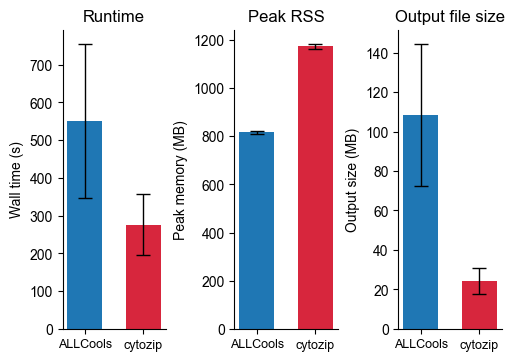

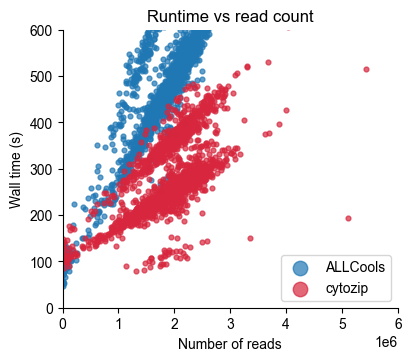

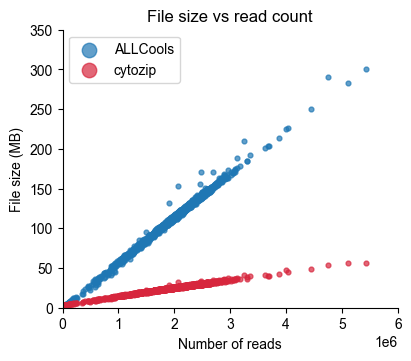

In [11]:
# ---- barplot: average runtime, peak memory & output size (mean +/- SD) -----
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

d = df.copy()
n = len(d)
c_allc, c_cz = '#1f77b4', '#d7263d'
x = np.arange(2)                       # two tools per panel

metrics = [
    ('allc_wall_s', 'cz_wall_s',  'Wall time (s)',      'Runtime'),
    ('allc_rss_mb', 'cz_rss_mb',  'Peak memory (MB)',   'Peak RSS'),
    ('allc_size_mb', 'cz_size_mb', 'Output size (MB)',  'Output file size'),
]

fig, axes = plt.subplots(1, 3, figsize=(5, 3.5), constrained_layout=True)

for ax, (a_col, c_col, ylabel, title) in zip(axes, metrics):
    means = [d[a_col].mean(), d[c_col].mean()]
    sds   = [d[a_col].std(),  d[c_col].std()]
    ax.bar(x, means, yerr=sds, capsize=5, color=[c_allc, c_cz],
           width=0.6, error_kw=dict(ecolor='black', lw=1))
    ax.set_xticks(x)
    ax.set_xticklabels(['ALLCools', 'cytozip'], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

tot_at, tot_ct = d['allc_wall_s'].sum(), d['cz_wall_s'].sum()
tot_as, tot_cs = d['allc_size_mb'].sum(), d['cz_size_mb'].sum()
# fig.suptitle(
#     f'BAM \u2192 ALLC vs BAM \u2192 CZ\n(n={n} cells, mean \u00b1 SD)   '
#     f'time: {tot_at:.0f} \u2192 {tot_ct:.0f} s '
#     f'({tot_at / max(tot_ct, 1e-9):.2f}\u00d7 faster)   '
#     f'mean RSS: {d["allc_rss_mb"].mean():.0f} \u2192 {d["cz_rss_mb"].mean():.0f} MB   '
#     f'size: {tot_as:.0f} \u2192 {tot_cs:.0f} MB '
#     f'({tot_cs / max(tot_as, 1e-9) * 100:.1f}%)',
#     fontsize=10,
# )

fig.savefig(BASE / 'bam_benchmark.pdf', bbox_inches='tight')
plt.show()

# ---- scatter plot: runtime vs number of reads (allc vs cz) ----------------
if 'n_reads' in d.columns:
    dl = d.dropna(subset=['n_reads'])
    fig2, ax2 = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
    ax2.scatter(dl['n_reads'], dl['allc_wall_s'], s=12, alpha=0.7,
                color=c_allc, label='ALLCools')
    ax2.scatter(dl['n_reads'], dl['cz_wall_s'], s=12, alpha=0.7,
                color=c_cz, label='cytozip')
    ax2.set_xlabel('Number of reads')
    ax2.set_ylabel('Wall time (s)')
    ax2.set_xlim(0,6e6)
    ax2.set_ylim(0,600)
    ax2.set_title('Runtime vs read count')
    ax2.legend(frameon=True, fontsize=10,markerscale=3)
    for s in ('top', 'right'):
        ax2.spines[s].set_visible(False)
    fig2.savefig(BASE / 'bam_benchmark.runtime_vs_reads.pdf', bbox_inches='tight')
    plt.show()

# ---- scatter plot: output file size vs number of reads (allc vs cz) --------
if 'n_reads' in d.columns:
    dl = d.dropna(subset=['n_reads'])
    fig3, ax3 = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
    ax3.scatter(dl['n_reads'], dl['allc_size_mb'], s=12, alpha=0.7,
                color=c_allc, label='ALLCools')
    ax3.scatter(dl['n_reads'], dl['cz_size_mb'], s=12, alpha=0.7,
                color=c_cz, label='cytozip')
    ax3.set_xlim(0,6e6)
    ax3.set_ylim(0, 350)
    ax3.set_xlabel('Number of reads')
    ax3.set_ylabel('File size (MB)')
    ax3.set_title('File size vs read count')
    ax3.legend(frameon=True, fontsize=10, markerscale=3)
    for s in ('top', 'right'):
        ax3.spines[s].set_visible(False)
    fig3.savefig(BASE / 'bam_benchmark.filesize_vs_reads.pdf', bbox_inches='tight')
    plt.show()

In [12]:
# runtime: 215 s for allc and 100s for .cz on average

## 3. Validate: do `allc` and `cz` store the same values?

Load the **entire** `allc` and `cz` files into memory and compare their
`(mc, cov)` values position-by-position. Any inconsistent record is printed.

Comparison rules (matching how each file stores data):

- **cz** is written in `mode='mc_cov'`, so it keeps only `[mc, cov]` aligned
  1:1 with the reference `.cz` positions. We recover coordinates from
  `REF_CZ` and **drop records with `cov == 0`** before comparing.
- **cz** stores counts as `uint8` (`count_fmt='B'`, max 255). Records whose
  **original allc `mc` or `cov` exceeds 255** are **excluded** from the
  comparison (they can't be matched exactly against the truncated cz value).
- ALLCools `bam_to_allc` has a known bug: the **last cytosine of every
  chromosome is dropped**. cz-only sites at each chromosome's last reference
  position are flagged separately (expected, not a real discrepancy).

We merge on `(chrom, pos)` and print every inconsistent record (value
mismatch, allc-only, or real cz-only).


In [13]:
# ---- helpers to load full allc / cz files for value comparison ------------
import numpy as np
from cytozip.cz import Reader
from cytozip.bam import _LazyRefPositions

# cz stores mc/cov as uint8 ('B'), max 255. We keep the RAW allc values and
# later EXCLUDE any record whose original mc/cov > 255 (can't be compared
# exactly against the truncated cz). cz mode='mc_cov' stores every reference
# position; records with cov == 0 are dropped.
COUNT_MAX = 255


def load_allc(allc_path):
    """Full ALLCools .allc.tsv.gz -> (chrom, pos, mc_allc, cov_allc), raw."""
    return pd.read_csv(
        allc_path, sep="\t", header=None, usecols=[0, 1, 4, 5],
        names=["chrom", "pos", "mc_allc", "cov_allc"],
        dtype={"chrom": str, "pos": np.int64,
               "mc_allc": np.int64, "cov_allc": np.int64},
    )


def load_cz_covered(cz_path, refpos):
    """Full mode='mc_cov' cz -> (chrom, pos, mc_cz, cov_cz), cov>0 only.

    Positions come from the row-aligned reference (`refpos`); records with
    cov == 0 are dropped. Also returns {chrom: last_ref_pos} so the caller
    can recognise the ALLCools "last cytosine of each chromosome is missing"
    bug.
    """
    cell = Reader(str(cz_path))
    frames, last_pos = [], {}
    for dim in cell.chunk_key2offset.keys():
        chrom = dim[-1]
        arr = cell.chunk2numpy(dim)          # f0=mc, f1=cov (uint8)
        mc, cov = arr["f0"], arr["f1"]
        pos = refpos.get(chrom)              # uint32, row-aligned with mc/cov
        if pos is None:
            continue
        if len(pos) != len(mc):
            raise ValueError(
                f"{cz_path} chrom {chrom}: {len(mc)} records but reference "
                f"has {len(pos)} positions (not row-aligned).")
        last_pos[chrom] = int(pos[-1]) if len(pos) else -1
        keep = cov > 0
        frames.append(pd.DataFrame({
            "chrom": chrom,
            "pos": pos[keep].astype(np.int64),
            "mc_cz": mc[keep].astype(np.int64),
            "cov_cz": cov[keep].astype(np.int64),
        }))
        refpos.drop(chrom)                   # release this chrom's ref pages
    cell.close()
    cz = (pd.concat(frames, ignore_index=True) if frames
          else pd.DataFrame(columns=["chrom", "pos", "mc_cz", "cov_cz"]))
    return cz, last_pos


# ---- randomly pick N_COMPARE cell(s) that have BOTH an allc and a cz output
N_COMPARE = 10     # how many cells to compare (whole files loaded in memory)
_paired = [p.name[:-3] for p in sorted(CZ_DIR.glob("*.cz"))
           if (ALLC_DIR / f"{p.name[:-3]}.allc.tsv.gz").exists()]
CMP_CIDS = sorted(random.Random(SEED).sample(_paired, min(N_COMPARE, len(_paired))))
print(f"will compare {len(CMP_CIDS)} cell(s):")
for cid in CMP_CIDS:
    print("  ", cid)


will compare 10 cell(s):
   UWA7648_CX1819_NAC_1_P1-1-I3-J17
   UWA7648_CX1819_NAC_1_P13-1-I24-B15
   UWA7648_CX1819_NAC_1_P15-1-L3-G5
   UWA7648_CX1819_NAC_1_P16-1-J7-A15
   UWA7648_CX1819_NAC_1_P2-1-E5-A14
   UWA7648_CX1819_NAC_1_P2-1-E5-G10
   UWA7648_CX1819_NAC_1_P6-1-M9-I14
   UWA7648_CX1819_NAC_1_P7-1-A11-P24
   UWA7648_CX1819_NAC_1_P8-1-I15-K8
   UWA7648_CX1819_NAC_1_P9-1-M14-M5


In [14]:
# ---- compare full allc vs cz per cell; print every inconsistent record ----
refpos = _LazyRefPositions(str(REF_CZ))     # streamed uint32 ref positions

for cid in CMP_CIDS:
    a = load_allc(ALLC_DIR / f"{cid}.allc.tsv.gz")          # whole allc
    c, last_pos = load_cz_covered(CZ_DIR / f"{cid}.cz", refpos)  # whole cz (cov>0)

    m = a.merge(c, on=["chrom", "pos"], how="outer", indicator=True)

    # EXCLUDE records affected by uint8 (255) truncation: any allc raw
    # mc/cov > 255 can't be compared exactly against the clipped cz value.
    truncated = ((m["mc_allc"] > COUNT_MAX) | (m["cov_allc"] > COUNT_MAX)).fillna(False)
    n_truncated = int(truncated.sum())
    m = m[~truncated].copy()

    both      = m["_merge"] == "both"
    cz_only   = m["_merge"] == "right_only"     # in cz (cov>0), not in allc
    allc_only = m["_merge"] == "left_only"      # in allc, cz cov==0 or absent

    # value mismatch on shared positions
    val_mis = both & ((m["mc_allc"] != m["mc_cz"]) | (m["cov_allc"] != m["cov_cz"]))

    # cz-only at each chrom's LAST reference position = known ALLCools
    # "drops the last cytosine of every chromosome" bug (not a cz error).
    m["last_pos"] = m["chrom"].map(last_pos)
    cz_only_lastC = cz_only & (m["pos"] == m["last_pos"])

    bad = m[val_mis | allc_only | (cz_only & ~cz_only_lastC)].copy()
    bad["issue"] = np.where(
        bad["_merge"] == "left_only", "allc_only",
        np.where(bad["_merge"] == "right_only", "cz_only", "value_mismatch"))

    print(f"\n===== {cid} =====")
    print(f"  allc records                 : {len(a):,}")
    print(f"  cz covered records (cov>0)   : {len(c):,}")
    print(f"  excluded (mc/cov > 255)      : {n_truncated:,}")
    print(f"  compared shared positions    : {int(both.sum()):,}")
    print(f"  value mismatches             : {int(val_mis.sum()):,}")
    print(f"  allc-only (cz cov==0/absent) : {int(allc_only.sum()):,}")
    print(f"  cz-only (real)               : {int((cz_only & ~cz_only_lastC).sum()):,}")
    print(f"  cz-only (ALLCools last-C bug): {int(cz_only_lastC.sum()):,}")

    if len(bad):
        cols = ["chrom", "pos", "mc_allc", "cov_allc", "mc_cz", "cov_cz", "issue"]
        print(f"\n  --- {len(bad):,} INCONSISTENT records ---")
        with pd.option_context("display.max_rows", None, "display.width", 200):
            print(bad[cols].sort_values(["chrom", "pos"]).to_string(index=False))
    else:
        print("  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)")

refpos.close()



===== UWA7648_CX1819_NAC_1_P1-1-I3-J17 =====
  allc records                 : 33,547,410
  cz covered records (cov>0)   : 33,547,410
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 33,547,410
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P13-1-I24-B15 =====
  allc records                 : 1,195
  cz covered records (cov>0)   : 1,195
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 1,195
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P15-1-L3-G5 =====
  allc records                 : 33,647,656
  cz covered records (cov>0)   : 33,647,656
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 33,647,656
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P16-1-J7-A15 =====
  allc records                 : 37,299,279
  cz covered records (cov>0)   : 37,299,279
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 37,299,279
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P2-1-E5-A14 =====
  allc records                 : 30,555,081
  cz covered records (cov>0)   : 30,555,081
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 30,555,081
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P2-1-E5-G10 =====
  allc records                 : 15,918,415
  cz covered records (cov>0)   : 15,918,415
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 15,918,415
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P6-1-M9-I14 =====
  allc records                 : 16,704,255
  cz covered records (cov>0)   : 16,704,255
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 16,704,255
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P7-1-A11-P24 =====
  allc records                 : 29,392,003
  cz covered records (cov>0)   : 29,392,003
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 29,392,003
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P8-1-I15-K8 =====
  allc records                 : 41,513,513
  cz covered records (cov>0)   : 41,513,513
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 41,513,513
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)



===== UWA7648_CX1819_NAC_1_P9-1-M14-M5 =====
  allc records                 : 16,845,297
  cz covered records (cov>0)   : 16,845,297
  excluded (mc/cov > 255)      : 0
  compared shared positions    : 16,845,297
  value mismatches             : 0
  allc-only (cz cov==0/absent) : 0
  cz-only (real)               : 0
  cz-only (ALLCools last-C bug): 0
  ✅ FULLY IDENTICAL (excluding 255-truncation & cov==0)


## 4. Benchmark: `allc2cz` (allc &rarr; cz) and compare with `bam_to_cz`

Convert every `benchmark/allc/<cell>.allc.tsv.gz` to a `.cz` file with
`cytozip.allc.allc2cz`, writing the results to `benchmark/allc2cz/<cell>.cz`
(created here). Each conversion runs as an isolated subprocess wrapped in
`/usr/bin/time -f '%e %M'` so **runtime** and **peak memory** are measured
independently per cell, and parallelised across cells.

Then:

- **Scatter plot**: X = number of covered cytosines per cell, Y = `allc2cz` runtime.
- **Consistency check**: compare `benchmark/cz/<cell>.cz` (from `bam_to_cz`)
  against `benchmark/allc2cz/<cell>.cz` (from `allc2cz`) position-by-position.
  Both are written in `mode='mc_cov'` with `uint8` (`'B'`) counts and are
  row-aligned to the same reference, so a direct array comparison is exact.


In [15]:
# ---- allc2cz benchmark: paths, call template, per-cell bench function ------
ALLC2CZ_DIR = BASE / "allc2cz"        # allc2cz outputs
ALLC2CZ_DIR.mkdir(parents=True, exist_ok=True)

# one isolated allc2cz call, timed with /usr/bin/time (reuses _time_child)
_ALLC2CZ_CALL = (
    "from cytozip.allc import allc2cz; "
    "allc2cz(input={allc!r}, output={out!r}, reference={ref!r})"
)

# incremental per-cell log for allc2cz (same pattern as the bam benchmark)
LOG_A2C_TSV = BASE / "allc2cz_benchmark.log.tsv"
_A2C_LOG_COLS = ["cell", "allc_size_mb", "a2c_ok", "a2c_wall_s",
                 "a2c_rss_mb", "a2c_cz_size_mb"]
_A2C_LOG_LOCK = threading.Lock()


def _append_a2c_log(row):
    line = "\t".join(str(row.get(c, "")) for c in _A2C_LOG_COLS)
    with _A2C_LOG_LOCK:
        new = (not LOG_A2C_TSV.exists()) or LOG_A2C_TSV.stat().st_size == 0
        with open(LOG_A2C_TSV, "a") as f:
            if new:
                f.write("\t".join(_A2C_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_a2c_log():
    if (not LOG_A2C_TSV.exists()) or LOG_A2C_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_A2C_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one_allc2cz(cid, prev_log=None):
    """Convert one allc.tsv.gz to cz with allc2cz, timing it in isolation.

    Skips (and reuses logged metrics) when the output .cz already exists.
    """
    prev_log = prev_log or {}
    allc_in = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out  = ALLC2CZ_DIR / f"{cid}.cz"

    if cz_out.exists() and cz_out.stat().st_size > 0:
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, allc_size_mb=allc_in.stat().st_size / 1e6,
                   a2c_cz_size_mb=cz_out.stat().st_size / 1e6)
        row.setdefault("a2c_ok", True)
        for k in ("a2c_wall_s", "a2c_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("a2c_err", "")
        row["skipped"] = True
        return row

    # allc2cz skips when output exists; start clean so timing reflects this run
    if cz_out.exists():
        cz_out.unlink()

    r = _time_child([PY, "-c", _ALLC2CZ_CALL.format(
        allc=str(allc_in), out=str(cz_out), ref=str(REF_CZ))])
    row = dict(
        cell=cid,
        allc_size_mb=allc_in.stat().st_size / 1e6,
        a2c_ok=r["ok"], a2c_wall_s=r["wall_s"], a2c_rss_mb=r["rss_mb"],
        a2c_cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        a2c_err=r["stderr_tail"], skipped=False,
    )
    _append_a2c_log(row)
    return row


# cells to convert = the allc files produced in section 2
a2c_cids = sorted(p.name[:-len(".allc.tsv.gz")]
                  for p in ALLC_DIR.glob("*.allc.tsv.gz"))
if N_CELLS is not None and len(a2c_cids) > N_CELLS:
    a2c_cids = sorted(random.Random(SEED).sample(a2c_cids, N_CELLS))
print(f"{len(a2c_cids)} allc file(s) to convert with allc2cz (JOBS={JOBS})")
print(f"  allc2cz -> {ALLC2CZ_DIR}")


2000 allc file(s) to convert with allc2cz (JOBS=64)
  allc2cz -> /home/x-wding2/Projects/test_cytozip/benchmark/allc2cz


In [16]:
# ---- run the allc2cz benchmark --------------------------------------------
prev_a2c = _load_a2c_log()      # reuse metrics for already-converted cells
t0 = time.perf_counter()
a2c_rows = []


def _report_a2c(i, r):
    if not r.get("a2c_ok", True):
        print(f"[{i:>3}/{len(a2c_cids)}] FAIL {r['cell']:<40} "
              f"a2c={r['a2c_wall_s']:6.1f}s/{r['a2c_rss_mb']:6.0f}MB", flush=True)
        print("     a2c_err:", r.get("a2c_err", "")[-300:])


if JOBS == 1:
    for i, cid in enumerate(a2c_cids, 1):
        r = bench_one_allc2cz(cid, prev_a2c)
        a2c_rows.append(r)
        _report_a2c(i, r)
else:
    with ThreadPoolExecutor(max_workers=JOBS) as ex:
        futs = {ex.submit(bench_one_allc2cz, cid, prev_a2c): cid for cid in a2c_cids}
        for i, fut in enumerate(as_completed(futs), 1):
            r = fut.result()
            a2c_rows.append(r)
            _report_a2c(i, r)
print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")



total wall-clock: 4748.5s


In [17]:
# ---- table + scatter: covered cytosines vs allc2cz runtime -----------------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
from cytozip.cz import Reader

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

tsv = BASE / "allc2cz_benchmark.tsv"


def _count_cytosines(cz_path):
    """Number of covered cytosines (cov > 0) stored in a mode='mc_cov' cz."""
    cell = Reader(str(cz_path))
    n = 0
    for dim in cell.chunk_key2offset.keys():
        arr = cell.chunk2numpy(dim)
        n += int((arr["f1"] > 0).sum())      # f1 = cov
    cell.close()
    return n


if tsv.exists() and tsv.stat().st_size > 0:
    # reuse the previously computed table (includes n_cytosines)
    dfa = pd.read_csv(tsv, sep="\t")
    print("read", tsv)
else:
    # load the incremental per-cell log
    if LOG_A2C_TSV.exists() and LOG_A2C_TSV.stat().st_size > 0:
        dfa = pd.read_csv(LOG_A2C_TSV, sep="\t").drop_duplicates(
            "cell", keep="last").sort_values("cell").reset_index(drop=True)
    else:
        dfa = pd.DataFrame(a2c_rows).drop(columns=["a2c_err"], errors="ignore")

    dfa = dfa[dfa["a2c_ok"] == True].reset_index(drop=True)
    if N_CELLS is not None and len(dfa) > N_CELLS:
        dfa = dfa.sample(n=N_CELLS, random_state=SEED).sort_values("cell").reset_index(drop=True)

    # count covered cytosines per cell in parallel (order-preserving)
    cz_paths = [str(ALLC2CZ_DIR / f"{c}.cz") for c in dfa["cell"]]
    with ProcessPoolExecutor(max_workers=JOBS) as ex:
        dfa["n_cytosines"] = list(ex.map(_count_cytosines, cz_paths))

    dfa.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
    print("wrote", tsv)

print(f"allc2cz: n={len(dfa)}  mean time={dfa['a2c_wall_s'].mean():.1f}s  "
      f"mean peak_rss={dfa['a2c_rss_mb'].mean():.0f}MB")


wrote /home/x-wding2/Projects/test_cytozip/benchmark/allc2cz_benchmark.tsv
allc2cz: n=2000  mean time=150.9s  mean peak_rss=3709MB


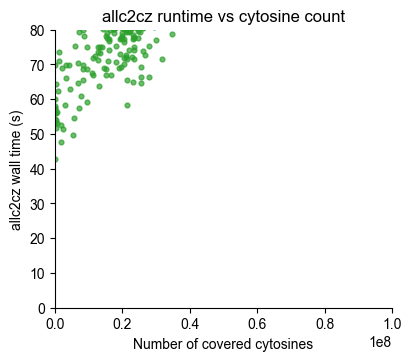

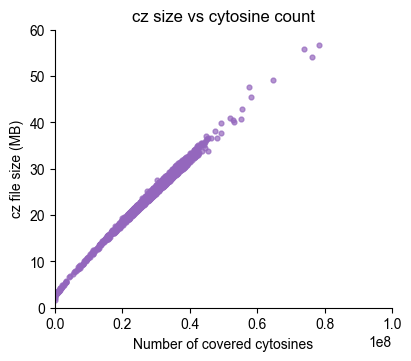

In [18]:
# scatter: X = number of covered cytosines, Y = allc2cz runtime
fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
ax.scatter(dfa["n_cytosines"], dfa["a2c_wall_s"], s=12, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Number of covered cytosines')
ax.set_ylabel('allc2cz wall time (s)')
ax.set_title('allc2cz runtime vs cytosine count')
ax.set_xlim(0, 1e8)
ax.set_ylim(0, 80)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.savefig(BASE / 'allc2cz_benchmark.runtime_vs_cytosines.pdf', bbox_inches='tight')
plt.show()

# scatter: X = number of covered cytosines, Y = cz output file size
fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
ax.scatter(dfa["n_cytosines"], dfa["a2c_cz_size_mb"], s=12, alpha=0.7, color='#9467bd')
ax.set_xlabel('Number of covered cytosines')
ax.set_ylabel('cz file size (MB)')
ax.set_xlim(0, 1e8)
ax.set_ylim(0, 60)
ax.set_title('cz size vs cytosine count')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.savefig(BASE / 'allc2cz_benchmark.czsize_vs_cytosines.pdf', bbox_inches='tight')
plt.show()


### Compare `bam_to_cz` cz vs `allc2cz` cz

For every cell with outputs in **both** `benchmark/cz/` (from `bam_to_cz`) and
`benchmark/allc2cz/` (from `allc2cz`), compare the two `.cz` files
position-by-position. Both are `mode='mc_cov'`, `uint8` counts, and row-aligned
to the same reference `.cz`, so the arrays line up 1:1 per chromosome and can be
compared directly. Any `(mc, cov)` mismatch is a real difference between calling
methylation from the BAM directly vs going through the ALLCools `allc` file.


In [19]:
# ---- compare bam_to_cz cz vs allc2cz cz, row-aligned per chromosome --------
from cytozip.cz import Reader

N_COMPARE=10
def compare_two_cz(cz_a, cz_b):
    """Compare two mode='mc_cov' cz files (row-aligned to same reference).

    Returns (n_positions, n_mismatch, list_of_detail_dicts).
    """
    ra, rb = Reader(str(cz_a)), Reader(str(cz_b))
    dims_a = set(ra.chunk_key2offset.keys())
    dims_b = set(rb.chunk_key2offset.keys())
    n_pos, n_mis, details = 0, 0, []
    for dim in sorted(dims_a | dims_b):
        chrom = dim[-1]
        if dim not in dims_a or dim not in dims_b:
            details.append(dict(chrom=chrom, issue="chrom missing in one file"))
            continue
        aa, bb = ra.chunk2numpy(dim), rb.chunk2numpy(dim)
        if len(aa) != len(bb):
            details.append(dict(chrom=chrom, issue="row count mismatch",
                                bam_cz=len(aa), allc2cz=len(bb)))
            continue
        diff = (aa["f0"] != bb["f0"]) | (aa["f1"] != bb["f1"])
        n_pos += len(aa)
        n_mis += int(diff.sum())
        if diff.any():
            details.append(dict(chrom=chrom, n_mismatch=int(diff.sum())))
    ra.close()
    rb.close()
    return n_pos, n_mis, details


# cells present in BOTH benchmark/cz and benchmark/allc2cz
_paired = sorted(p.name[:-3] for p in ALLC2CZ_DIR.glob("*.cz")
                 if (CZ_DIR / f"{p.name[:-3]}.cz").exists())
if N_COMPARE is not None and len(_paired) > N_COMPARE:
    _paired = sorted(random.Random(SEED).sample(_paired, N_COMPARE))
print(f"comparing {len(_paired)} cell(s): bam_to_cz vs allc2cz\n")

tot_pos, tot_mis, n_identical = 0, 0, 0
for cid in _paired:
    n_pos, n_mis, details = compare_two_cz(
        CZ_DIR / f"{cid}.cz", ALLC2CZ_DIR / f"{cid}.cz")
    tot_pos += n_pos
    tot_mis += n_mis
    status = "IDENTICAL" if n_mis == 0 and not details else f"{n_mis:,} mismatches"
    if n_mis == 0 and not details:
        n_identical += 1
    print(f"  {cid:<45} {n_pos:>12,} positions  {status}")
    for d in details:
        print("       ", d)

print(f"\n===== summary =====")
print(f"  cells compared            : {len(_paired)}")
print(f"  fully identical           : {n_identical}")
print(f"  total positions compared  : {tot_pos:,}")
print(f"  total (mc,cov) mismatches : {tot_mis:,}"
      f"  ({tot_mis / max(tot_pos, 1) * 100:.4g}%)")


comparing 10 cell(s): bam_to_cz vs allc2cz



  UWA7648_CX1819_NAC_1_P1-1-I3-J17              1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P13-1-I24-B15            1,053,724,560 positions  0 mismatches
        {'chrom': 'chr10', 'issue': 'chrom missing in one file'}
        {'chrom': 'chr16', 'issue': 'chrom missing in one file'}
        {'chrom': 'chr20', 'issue': 'chrom missing in one file'}
        {'chrom': 'chr21', 'issue': 'chrom missing in one file'}
        {'chrom': 'chrL', 'issue': 'chrom missing in one file'}
        {'chrom': 'chrM', 'issue': 'chrom missing in one file'}
        {'chrom': 'chrY', 'issue': 'chrom missing in one file'}


  UWA7648_CX1819_NAC_1_P15-1-L3-G5              1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P16-1-J7-A15             1,200,583,204 positions  IDENTICAL


...

  UWA7648_CX1819_NAC_1_P2-1-E5-G10              1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P6-1-M9-I14              1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P7-1-A11-P24             1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P8-1-I15-K8              1,200,583,204 positions  IDENTICAL


  UWA7648_CX1819_NAC_1_P9-1-M14-M5              1,200,583,204 positions  IDENTICAL

===== summary =====
  cells compared            : 10
  fully identical           : 9
  total positions compared  : 11,858,973,396
  total (mc,cov) mismatches : 0  (0%)


In [20]:
# Query
! czip query -I benchmark/allc2cz/UWA7648_CX1819_NAC_1_P1-1-I3-J17.cz \
    -r ~/Ref/hg38/hg38_with_chrL.allc.cz -K chr9 -s 3000000 -e 3005000 | awk 'BEGIN{FS=OFS="\t"};{if(NR==1 || $6>0){print($0)}}'

chrom	pos	strand	context	mc	cov
chr9	3000596	-	CGG	1	1
chr9	3000603	-	CAT	0	1
chr9	3000604	-	CCA	0	1
chr9	3000608	-	CAG	0	1
chr9	3000612	-	CTG	0	1
chr9	3000613	-	CCT	0	1
chr9	3000620	-	CAG	0	1
chr9	3000622	-	CTC	0	1
chr9	3000631	-	CAG	0	1
chr9	3000632	-	CCA	0	1
chr9	3000633	-	CCC	0	1
chr9	3000636	-	CTG	0	1
chr9	3000642	-	CTG	0	1
chr9	3000646	-	CTT	0	1
chr9	3000648	-	CTC	0	1
chr9	3000649	-	CCT	0	1
chr9	3000651	-	CTC	0	1
chr9	3000652	-	CCT	0	1
chr9	3000655	-	CAG	0	1
chr9	3000660	-	CTG	0	1
chr9	3000667	-	CAA	0	1
chr9	3000670	-	CTG	0	1
chr9	3000672	-	CAC	0	1
chr9	3002113	-	CTT	0	1
chr9	3002116	-	CGA	1	1
chr9	3002127	-	CAA	0	1
chr9	3002131	-	CAG	0	1
chr9	3002137	-	CTA	0	1
chr9	3002145	-	CAA	0	1
chr9	3002147	-	CTC	0	1
chr9	3002151	-	CTG	0	1
chr9	3002152	-	CCT	0	1


In [21]:
# Query
! czip query -I benchmark/cz/UWA7648_CX1819_NAC_1_P1-1-I3-J17.cz \
    -r ~/Ref/hg38/hg38_with_chrL.allc.cz -K chr9 -s 3000000 -e 3005000 | awk 'BEGIN{FS=OFS="\t"};{if(NR==1 || $6>0){print($0)}}'

chrom	pos	strand	context	mc	cov
chr9	3000596	-	CGG	1	1
chr9	3000603	-	CAT	0	1
chr9	3000604	-	CCA	0	1
chr9	3000608	-	CAG	0	1
chr9	3000612	-	CTG	0	1
chr9	3000613	-	CCT	0	1
chr9	3000620	-	CAG	0	1
chr9	3000622	-	CTC	0	1
chr9	3000631	-	CAG	0	1
chr9	3000632	-	CCA	0	1
chr9	3000633	-	CCC	0	1
chr9	3000636	-	CTG	0	1
chr9	3000642	-	CTG	0	1
chr9	3000646	-	CTT	0	1
chr9	3000648	-	CTC	0	1
chr9	3000649	-	CCT	0	1
chr9	3000651	-	CTC	0	1
chr9	3000652	-	CCT	0	1
chr9	3000655	-	CAG	0	1
chr9	3000660	-	CTG	0	1
chr9	3000667	-	CAA	0	1
chr9	3000670	-	CTG	0	1
chr9	3000672	-	CAC	0	1
chr9	3002113	-	CTT	0	1
chr9	3002116	-	CGA	1	1
chr9	3002127	-	CAA	0	1
chr9	3002131	-	CAG	0	1
chr9	3002137	-	CTA	0	1
chr9	3002145	-	CAA	0	1
chr9	3002147	-	CTC	0	1
chr9	3002151	-	CTG	0	1
chr9	3002152	-	CCT	0	1
